import libraries

In [46]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

download data

In [47]:
ticker = ["AAPL", "NVDA", "AMZN", "TSLA", "JPM"]

all_ticker_data = []

for ticker_symbol in ticker:

    ticker_data = yf.download(
        ticker_symbol,
        period="5y",
        auto_adjust=False
    )

    ticker_data.columns = ticker_data.columns.get_level_values(0)

    ticker_data = ticker_data.reset_index()

    ticker_data["Ticker"] = ticker_symbol

    all_ticker_data.append(ticker_data)

df = pd.concat(all_ticker_data, ignore_index=True)

df

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Price,Date,Adj Close,Close,High,Low,Open,Volume,Ticker
0,2021-09-10,145.301056,148.970001,155.479996,148.699997,155.000000,140893200,AAPL
1,2021-09-13,145.866791,149.550003,151.419998,148.750000,150.630005,102404300,AAPL
2,2021-09-14,144.471970,148.119995,151.070007,146.910004,150.350006,109296300,AAPL
3,2021-09-15,145.359558,149.029999,149.440002,146.369995,148.559998,83281300,AAPL
4,2021-09-16,145.125504,148.789993,148.970001,147.220001,148.440002,68034100,AAPL
...,...,...,...,...,...,...,...,...
6270,2026-09-03,362.059998,362.059998,362.850006,356.390015,358.679993,5414200,JPM
6271,2026-09-04,358.640015,358.640015,362.859985,355.200012,361.000000,4873500,JPM
6272,2026-09-08,353.510010,353.510010,358.549988,353.230011,357.100006,5631400,JPM
6273,2026-09-09,354.709991,354.709991,356.329987,348.690002,352.000000,6318200,JPM


In [48]:
df.head()

Price,Date,Adj Close,Close,High,Low,Open,Volume,Ticker
0,2021-09-10,145.301056,148.970001,155.479996,148.699997,155.000000,140893200,AAPL
1,2021-09-13,145.866791,149.550003,151.419998,148.750000,150.630005,102404300,AAPL
2,2021-09-14,144.471970,148.119995,151.070007,146.910004,150.350006,109296300,AAPL
3,2021-09-15,145.359558,149.029999,149.440002,146.369995,148.559998,83281300,AAPL
4,2021-09-16,145.125504,148.789993,148.970001,147.220001,148.440002,68034100,AAPL


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6275 entries, 0 to 6274
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       6275 non-null   datetime64[ns]
 1   Adj Close  6275 non-null   float64       
 2   Close      6275 non-null   float64       
 3   High       6275 non-null   float64       
 4   Low        6275 non-null   float64       
 5   Open       6275 non-null   float64       
 6   Volume     6275 non-null   int64         
 7   Ticker     6275 non-null   object        
dtypes: datetime64[ns](1), float64(5), int64(1), object(1)
memory usage: 392.3+ KB


In [50]:
df.describe()

Price,Date,Adj Close,Close,High,Low,Open,Volume
count,6275,6275.000000,6275.000000,6275.000000,6275.000000,6275.000000,6.275000e+03
mean,2024-03-10 01:42:07.171314944,190.181607,192.350685,195.129545,189.449465,192.321846,1.186630e+08
min,2021-09-10 00:00:00,11.199244,11.227000,11.735000,10.813000,10.971000,2.330785e+06
25%,2022-12-07 00:00:00,133.034409,138.299995,140.080002,136.605003,138.544998,3.459805e+07
50%,2024-03-11 00:00:00,182.500000,183.380005,185.860001,181.220001,183.740005,6.148000e+07
75%,2025-06-11 00:00:00,241.365379,243.639999,247.464996,240.354996,243.995003,1.222985e+08
max,2026-09-10 00:00:00,489.880005,489.880005,498.829987,485.329987,489.880005,1.543911e+09
std,NaN,92.179563,91.733313,93.351464,90.112332,91.769469,1.563389e+08


In [51]:
df.shape

(6275, 8)

In [52]:
df.columns

Index(['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume',
       'Ticker'],
      dtype='object', name='Price')

Question 1 — Overall performance

In [53]:
df1 = df[["Date", "Ticker", "Adj Close"]]
df1.columns = ['date', 'ticker', 'price']
df1


,date,ticker,price
0,2021-09-10,AAPL,145.301056
1,2021-09-13,AAPL,145.866791
2,2021-09-14,AAPL,144.471970
3,2021-09-15,AAPL,145.359558
4,2021-09-16,AAPL,145.125504
...,...,...,...
6270,2026-09-03,JPM,362.059998
6271,2026-09-04,JPM,358.640015
6272,2026-09-08,JPM,353.510010
6273,2026-09-09,JPM,354.709991


In [54]:
df1 = df1.pivot_table(index=['date'], columns='ticker', values=['price'])
df1.columns = [col[1] for col in df1.columns.values]
df1

,AAPL,AMZN,JPM,NVDA,TSLA
date,,,,,
2021-09-10,145.301056,173.457504,138.855469,22.404467,245.423340
2021-09-13,145.866791,172.858505,141.061493,22.079535,247.666672
2021-09-14,144.471970,172.500000,138.599579,22.169243,248.163330
2021-09-15,145.359558,173.789505,139.561417,22.267920,251.943329
2021-09-16,145.125504,174.412003,139.499634,22.169243,252.330002
...,...,...,...,...,...
2026-09-03,328.209991,258.899994,362.059998,228.449997,376.369995
2026-09-04,319.970001,258.510010,358.640015,230.360001,354.079987
2026-09-08,316.220001,256.970001,353.510010,225.729996,368.160004


In [55]:
overall_performance = (df1.iloc[-1] - df1.iloc[0]) / df1.iloc[0]
overall_performance * 100

AAPL    123.945371
AMZN     45.407374
JPM     153.727855
NVDA    874.314617
TSLA     49.350102
dtype: float64

Question 2 — Daily returns

In [56]:
daily_return = df1.pct_change().dropna()
daily_return

,AAPL,AMZN,JPM,NVDA,TSLA
date,,,,,
2021-09-13,0.003894,-0.003453,0.015887,-0.014503,0.009141
2021-09-14,-0.009562,-0.002074,-0.017453,0.004063,0.002005
2021-09-15,0.006144,0.007475,0.006940,0.004451,0.015232
2021-09-16,-0.001610,0.003582,-0.000443,-0.004431,0.001535
2021-09-17,-0.018348,-0.007373,-0.002594,-0.015376,0.003303
...,...,...,...,...,...
2026-09-03,0.010001,0.015374,0.016394,0.018003,0.054228
2026-09-04,-0.025106,-0.001506,-0.009446,0.008361,-0.059224
2026-09-08,-0.011720,-0.005957,-0.014304,-0.020099,0.039765


Question 3 — Volatility

In [57]:
volatility = (
    daily_return.std().round(2)
)


In [58]:
volatility

AAPL    0.02
AMZN    0.02
JPM     0.02
NVDA    0.03
TSLA    0.04
dtype: float64

Question 4 — Moving averages(MA7)

In [59]:
df["MA7"] = (
    df
    .groupby("Ticker")["Adj Close"]
    .transform(
        lambda x:
        x.rolling(7).mean()
    )
)
df

Price,Date,Adj Close,Close,High,Low,Open,Volume,Ticker,MA7
0,2021-09-10,145.301056,148.970001,155.479996,148.699997,155.000000,140893200,AAPL,NaN
1,2021-09-13,145.866791,149.550003,151.419998,148.750000,150.630005,102404300,AAPL,NaN
2,2021-09-14,144.471970,148.119995,151.070007,146.910004,150.350006,109296300,AAPL,NaN
3,2021-09-15,145.359558,149.029999,149.440002,146.369995,148.559998,83281300,AAPL,NaN
4,2021-09-16,145.125504,148.789993,148.970001,147.220001,148.440002,68034100,AAPL,NaN
...,...,...,...,...,...,...,...,...,...
6270,2026-09-03,362.059998,362.059998,362.850006,356.390015,358.679993,5414200,JPM,356.798571
6271,2026-09-04,358.640015,358.640015,362.859985,355.200012,361.000000,4873500,JPM,357.104287
6272,2026-09-08,353.510010,353.510010,358.549988,353.230011,357.100006,5631400,JPM,357.002860
6273,2026-09-09,354.709991,354.709991,356.329987,348.690002,352.000000,6318200,JPM,356.587145


Question 4 — Moving averages(MA30)

In [60]:
df["MA30"] = (
    df
    .groupby("Ticker")["Adj Close"]
    .transform(
        lambda x:
        x.rolling(30).mean()
    )
)
df

Price,Date,Adj Close,Close,High,Low,Open,Volume,Ticker,MA7,MA30
0,2021-09-10,145.301056,148.970001,155.479996,148.699997,155.000000,140893200,AAPL,NaN,NaN
1,2021-09-13,145.866791,149.550003,151.419998,148.750000,150.630005,102404300,AAPL,NaN,NaN
2,2021-09-14,144.471970,148.119995,151.070007,146.910004,150.350006,109296300,AAPL,NaN,NaN
3,2021-09-15,145.359558,149.029999,149.440002,146.369995,148.559998,83281300,AAPL,NaN,NaN
4,2021-09-16,145.125504,148.789993,148.970001,147.220001,148.440002,68034100,AAPL,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
6270,2026-09-03,362.059998,362.059998,362.850006,356.390015,358.679993,5414200,JPM,356.798571,356.850665
6271,2026-09-04,358.640015,358.640015,362.859985,355.200012,361.000000,4873500,JPM,357.104287,357.031666
6272,2026-09-08,353.510010,353.510010,358.549988,353.230011,357.100006,5631400,JPM,357.002860,356.941999
6273,2026-09-09,354.709991,354.709991,356.329987,348.690002,352.000000,6318200,JPM,356.587145,356.855332


Question 4 — Moving averages(MA90)

In [61]:
df["MA90"] = (
    df
    .groupby("Ticker")["Adj Close"]
    .transform(
        lambda x:
        x.rolling(90).mean()
    )
)
df

Price,Date,Adj Close,Close,High,Low,Open,Volume,Ticker,MA7,MA30,MA90
0,2021-09-10,145.301056,148.970001,155.479996,148.699997,155.000000,140893200,AAPL,NaN,NaN,NaN
1,2021-09-13,145.866791,149.550003,151.419998,148.750000,150.630005,102404300,AAPL,NaN,NaN,NaN
2,2021-09-14,144.471970,148.119995,151.070007,146.910004,150.350006,109296300,AAPL,NaN,NaN,NaN
3,2021-09-15,145.359558,149.029999,149.440002,146.369995,148.559998,83281300,AAPL,NaN,NaN,NaN
4,2021-09-16,145.125504,148.789993,148.970001,147.220001,148.440002,68034100,AAPL,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
6270,2026-09-03,362.059998,362.059998,362.850006,356.390015,358.679993,5414200,JPM,356.798571,356.850665,331.080479
6271,2026-09-04,358.640015,358.640015,362.859985,355.200012,361.000000,4873500,JPM,357.104287,357.031666,331.620332
6272,2026-09-08,353.510010,353.510010,358.549988,353.230011,357.100006,5631400,JPM,357.002860,356.941999,332.127520
6273,2026-09-09,354.709991,354.709991,356.329987,348.690002,352.000000,6318200,JPM,356.587145,356.855332,332.604017


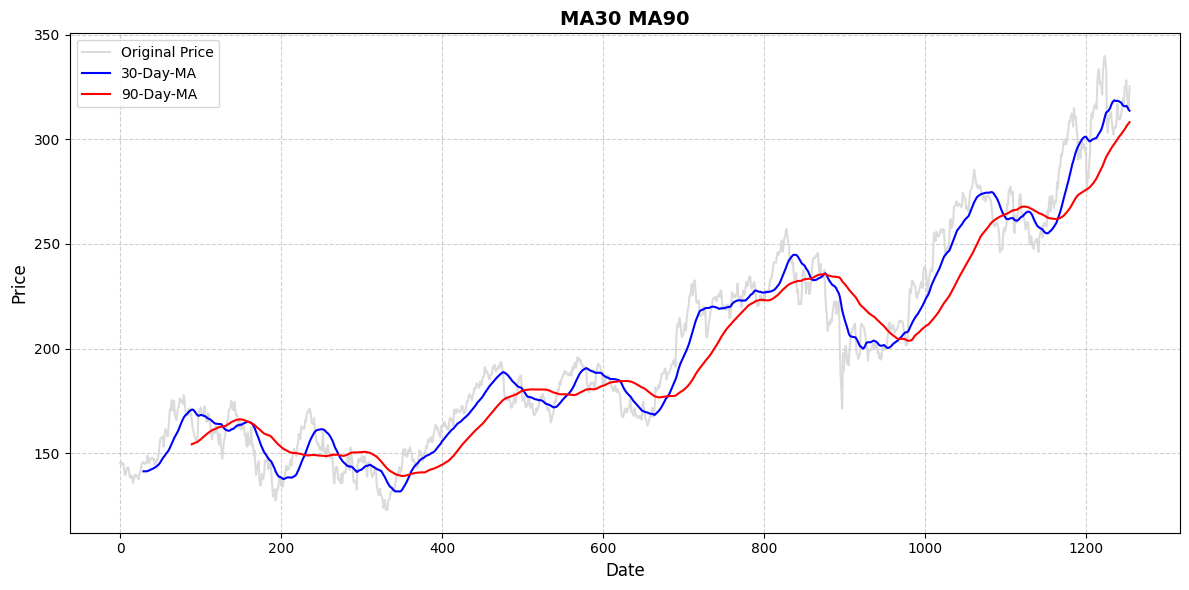

In [62]:
aapl = df[
    df["Ticker"] == "AAPL"
]

plt.figure(figsize=(12,6))

plt.plot(aapl["Adj Close"], label="Original Price", color="lightgray", alpha=0.8)
plt.plot(aapl["MA30"], label="30-Day-MA", color="blue", linewidth=1.5)
plt.plot(aapl["MA90"], label="90-Day-MA", color="red", linewidth=1.5)

plt.title("MA30 MA90", fontsize=14, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()

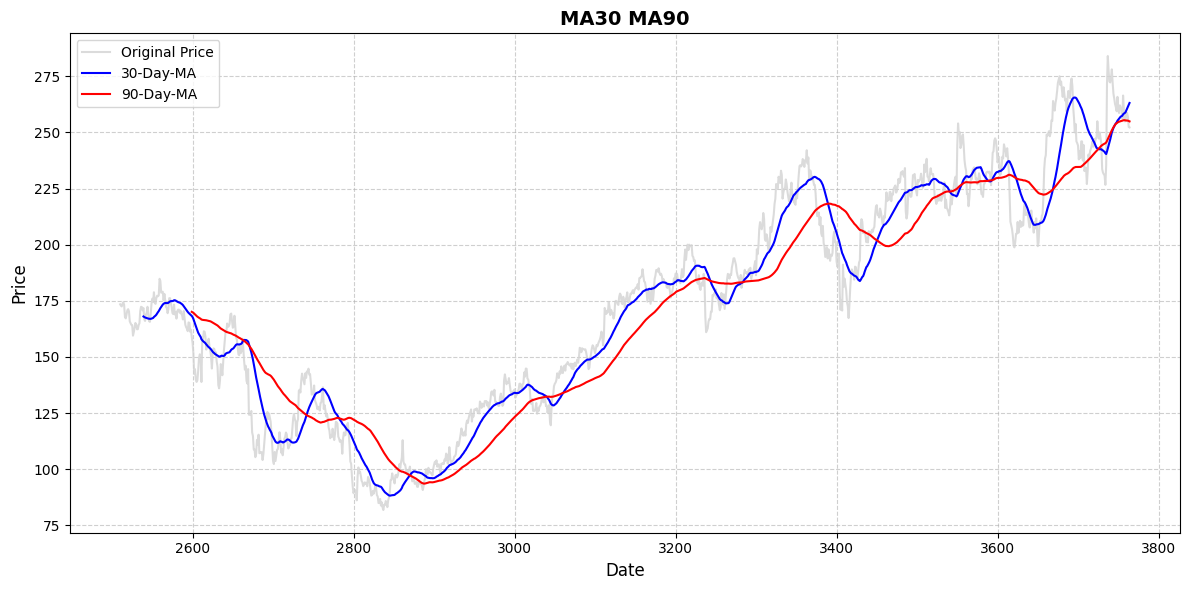

In [63]:
amzn = df[
    df["Ticker"] == "AMZN"
]

plt.figure(figsize=(12,6))

plt.plot(amzn["Adj Close"], label="Original Price", color="lightgray", alpha=0.8)
plt.plot(amzn["MA30"], label="30-Day-MA", color="blue", linewidth=1.5)
plt.plot(amzn["MA90"], label="90-Day-MA", color="red", linewidth=1.5)

plt.title("MA30 MA90", fontsize=14, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()

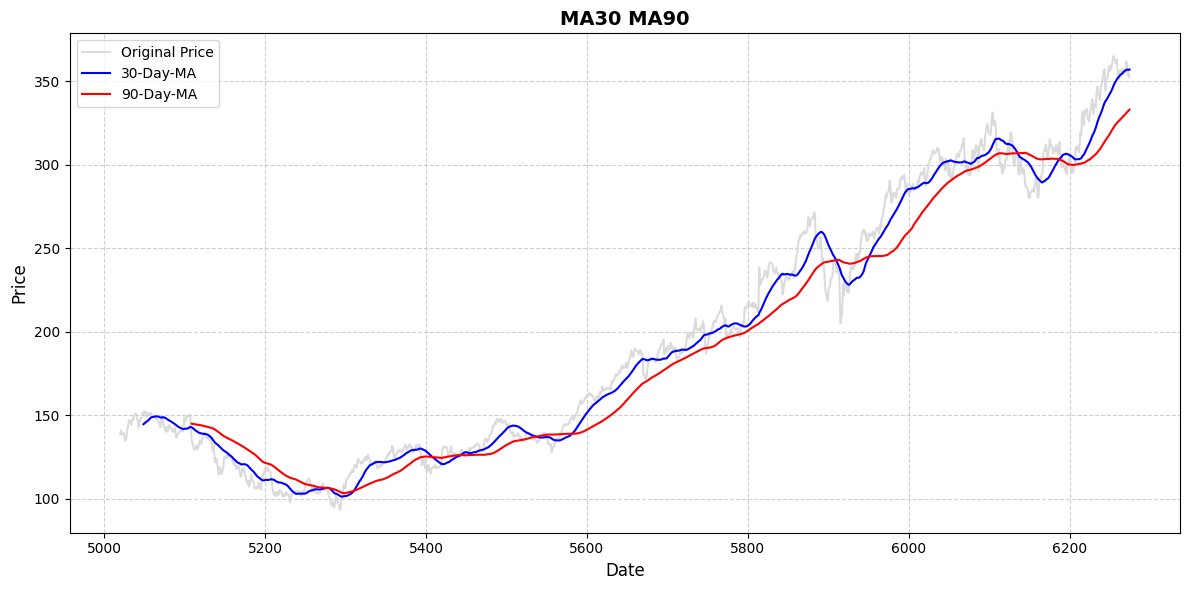

In [64]:
jpm = df[
    df["Ticker"] == "JPM"
]

plt.figure(figsize=(12,6))

plt.plot(jpm["Adj Close"], label="Original Price", color="lightgray", alpha=0.8)
plt.plot(jpm["MA30"], label="30-Day-MA", color="blue", linewidth=1.5)
plt.plot(jpm["MA90"], label="90-Day-MA", color="red", linewidth=1.5)

plt.title("MA30 MA90", fontsize=14, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()

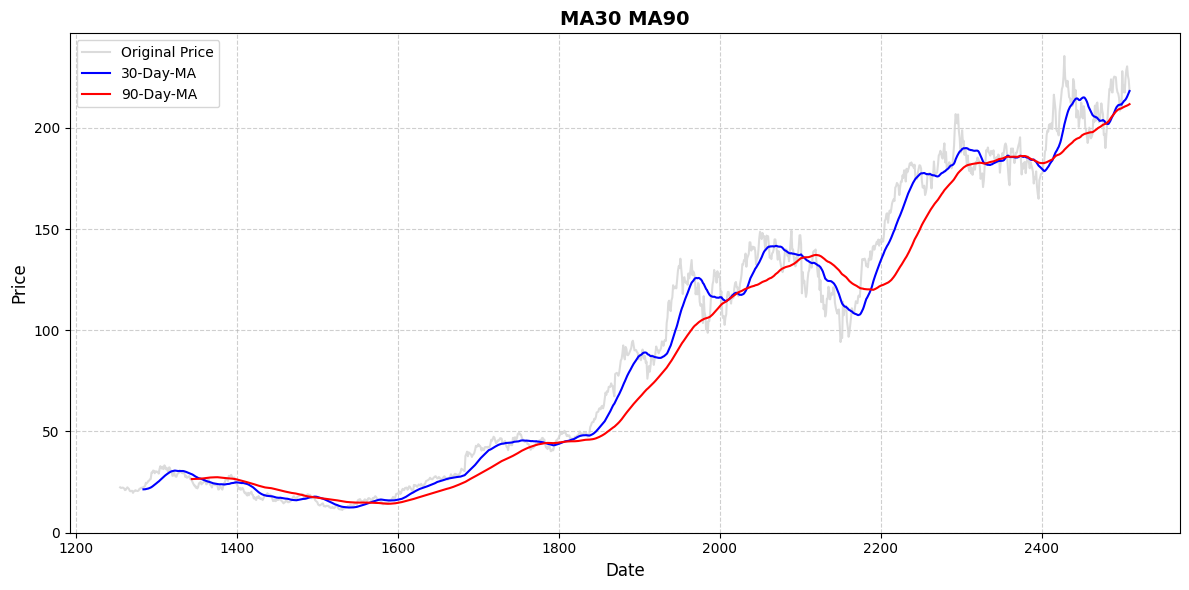

In [65]:
nvda = df[
    df["Ticker"] == "NVDA"
]

plt.figure(figsize=(12,6))

plt.plot(nvda["Adj Close"], label="Original Price", color="lightgray", alpha=0.8)
plt.plot(nvda["MA30"], label="30-Day-MA", color="blue", linewidth=1.5)
plt.plot(nvda["MA90"], label="90-Day-MA", color="red", linewidth=1.5)

plt.title("MA30 MA90", fontsize=14, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()

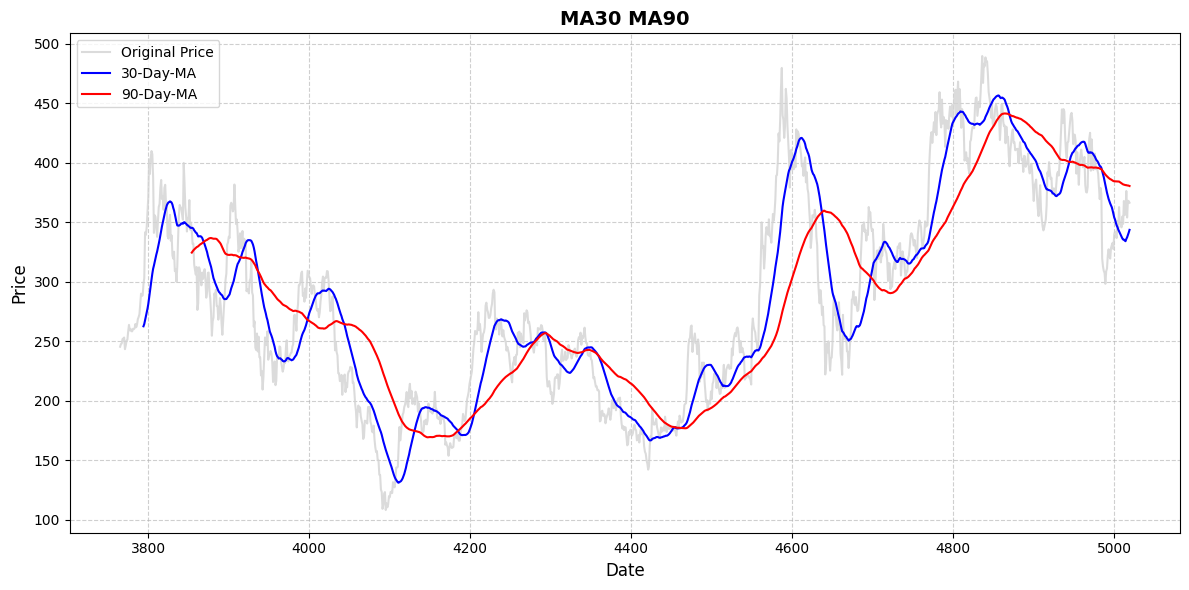

In [66]:
tsla = df[
    df["Ticker"] == "TSLA"
]

plt.figure(figsize=(12,6))

plt.plot(tsla["Adj Close"], label="Original Price", color="lightgray", alpha=0.8)
plt.plot(tsla["MA30"], label="30-Day-MA", color="blue", linewidth=1.5)
plt.plot(tsla["MA90"], label="90-Day-MA", color="red", linewidth=1.5)

plt.title("MA30 MA90", fontsize=14, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()

Question 5 — Best and worst days

In [67]:
best_days = {}
worst_days = {}

for ticker in daily_return.columns:

    best_days[ticker] = daily_return[ticker].nlargest(10)
    worst_days[ticker] = daily_return[ticker].nsmallest(10)

In [68]:
best_days["AAPL"]

date
2025-04-09    0.153289
2022-11-10    0.088975
2022-10-28    0.075552
2024-06-11    0.072649
2022-01-28    0.069778
2025-05-12    0.063146
2024-05-03    0.059816
2025-08-06    0.050907
2022-11-30    0.048594
2026-07-02    0.048407
Name: AAPL, dtype: float64

In [69]:
worst_days["AAPL"]

date
2025-04-03   -0.092456
2026-07-31   -0.073539
2025-04-04   -0.072887
2026-06-25   -0.061178
2022-09-13   -0.058680
2022-05-18   -0.056419
2022-05-05   -0.055716
2022-05-11   -0.051841
2026-02-12   -0.049982
2025-04-08   -0.049818
Name: AAPL, dtype: float64

In [70]:
best_days["AMZN"]

date
2026-07-31    0.153206
2022-02-04    0.135359
2022-11-10    0.121778
2025-04-09    0.119770
2022-07-29    0.103615
2025-10-31    0.095845
2023-08-04    0.082693
2025-05-12    0.080700
2024-02-02    0.078666
2023-02-02    0.073799
Name: AMZN, dtype: float64

In [71]:
worst_days["AMZN"]

date
2022-04-29   -0.140494
2025-04-03   -0.089791
2024-08-02   -0.087847
2023-02-03   -0.084315
2025-08-01   -0.082696
2022-02-03   -0.078128
2022-05-05   -0.075610
2022-05-18   -0.071562
2022-09-13   -0.070575
2022-10-28   -0.068042
Name: AMZN, dtype: float64

In [72]:
best_days["JPM"]

date
2024-11-06    0.115445
2025-04-09    0.080555
2023-04-14    0.075510
2022-05-23    0.061872
2022-10-13    0.055593
2022-10-21    0.052527
2022-10-04    0.046784
2022-07-15    0.045833
2022-03-16    0.044686
2024-10-11    0.044400
Name: JPM, dtype: float64

In [73]:
worst_days["JPM"]

date
2025-04-04   -0.074838
2025-04-03   -0.069685
2024-04-12   -0.064678
2022-01-14   -0.061463
2023-03-09   -0.054136
2024-09-10   -0.051889
2023-03-15   -0.047244
2025-12-09   -0.046635
2022-06-10   -0.045966
2024-05-20   -0.044973
Name: JPM, dtype: float64

In [74]:
best_days["NVDA"]

date
2023-05-25    0.243696
2025-04-09    0.187227
2024-02-22    0.164009
2022-11-10    0.143293
2023-02-23    0.140214
2024-07-31    0.128121
2021-11-04    0.120423
2022-03-24    0.098151
2022-05-13    0.094652
2024-05-23    0.093197
Name: NVDA, dtype: float64

In [75]:
worst_days["NVDA"]

date
2025-01-27   -0.169682
2024-04-19   -0.100046
2024-09-03   -0.095250
2022-09-13   -0.094726
2022-05-09   -0.092370
2022-08-26   -0.092279
2025-03-03   -0.086936
2025-02-27   -0.084781
2022-10-07   -0.080274
2022-06-13   -0.078178
Name: NVDA, dtype: float64

In [76]:
best_days["TSLA"]

date
2025-04-09    0.226900
2024-10-24    0.219190
2024-04-29    0.153069
2024-11-06    0.147510
2022-01-03    0.135317
2021-10-25    0.126616
2024-04-24    0.120611
2025-03-24    0.119336
2023-01-27    0.110002
2023-01-26    0.109673
Name: TSLA, dtype: float64

In [77]:
worst_days["TSLA"]

date
2025-03-10   -0.154262
2026-07-23   -0.145237
2025-06-05   -0.142599
2024-07-24   -0.123346
2023-01-03   -0.122422
2022-04-26   -0.121841
2024-01-25   -0.121253
2021-11-09   -0.119903
2022-01-27   -0.115542
2022-12-27   -0.114089
Name: TSLA, dtype: float64

Question 6 — Correlation

In [78]:
correlation = daily_return.corr()

correlation

,AAPL,AMZN,JPM,NVDA,TSLA
AAPL,1.000000,0.492713,0.361642,0.471963,0.461842
AMZN,0.492713,1.000000,0.354145,0.523106,0.435679
JPM,0.361642,0.354145,1.000000,0.324590,0.317993
NVDA,0.471963,0.523106,0.324590,1.000000,0.461834
TSLA,0.461842,0.435679,0.317993,0.461834,1.000000


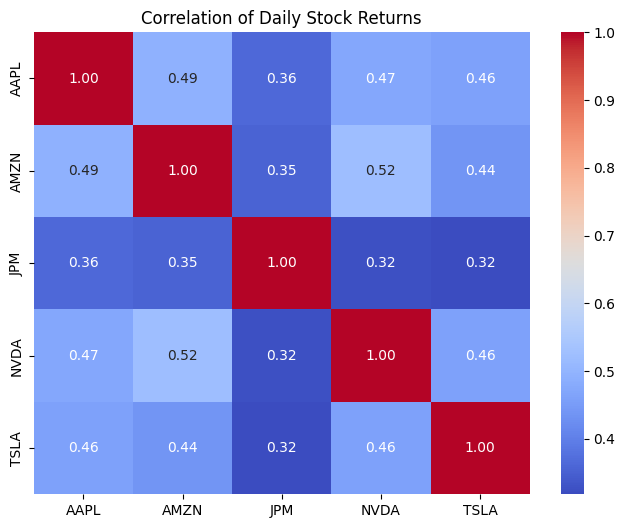

In [79]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation of Daily Stock Returns")

plt.show()

Question 7 — Risk vs Return

In [80]:
annual_return = daily_return.mean() * 252

In [81]:
annual_return

AAPL    0.201257
AMZN    0.141393
JPM     0.216949
NVDA    0.591764
TSLA    0.259196
dtype: float64

In [82]:
annual_volatility = daily_return.std() * np.sqrt(252)

In [83]:
risk_return = pd.DataFrame({
    "Annual Return": annual_return,
    "Annual Volatility": annual_volatility
})

risk_return

,Annual Return,Annual Volatility
AAPL,0.201257,0.280614
AMZN,0.141393,0.364651
JPM,0.216949,0.244229
NVDA,0.591764,0.520408
TSLA,0.259196,0.598919


In [84]:
risk_return["Annual Return %"] = (
    risk_return["Annual Return"] * 100
)

risk_return["Annual Volatility %"] = (
    risk_return["Annual Volatility"] * 100
)

In [85]:
risk_return

,Annual Return,Annual Volatility,Annual Return %,Annual Volatility %
AAPL,0.201257,0.280614,20.125713,28.061437
AMZN,0.141393,0.364651,14.139339,36.465067
JPM,0.216949,0.244229,21.694897,24.422876
NVDA,0.591764,0.520408,59.176404,52.040786
TSLA,0.259196,0.598919,25.919599,59.891860


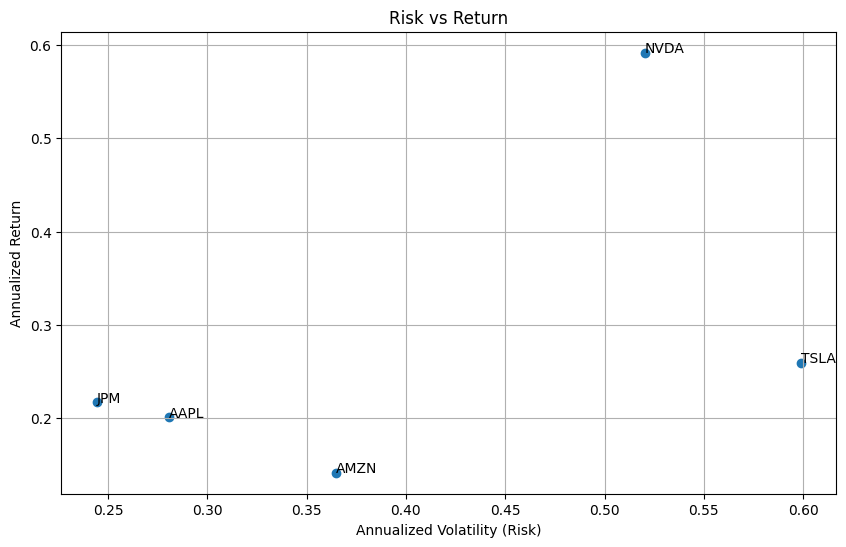

In [86]:
plt.figure(figsize=(10, 6))

plt.scatter(
    risk_return["Annual Volatility"],
    risk_return["Annual Return"]
)

for ticker in risk_return.index:

    plt.annotate(
        ticker,
        (
            risk_return.loc[ticker, "Annual Volatility"],
            risk_return.loc[ticker, "Annual Return"]
        )
    )

plt.xlabel("Annualized Volatility (Risk)")
plt.ylabel("Annualized Return")
plt.title("Risk vs Return")

plt.grid(True)

plt.show()

Extra Question — Risk Adjusted Return

In [87]:
risk_return["Risk Adjusted Return"] = risk_return["Annual Return"] / risk_return["Annual Volatility"]

In [88]:
risk_return["Risk Adjusted Return%"] = (risk_return["Risk Adjusted Return"] * 100)
risk_return

,Annual Return,Annual Volatility,Annual Return %,Annual Volatility %,Risk Adjusted Return,Risk Adjusted Return%
AAPL,0.201257,0.280614,20.125713,28.061437,0.717202,71.720180
AMZN,0.141393,0.364651,14.139339,36.465067,0.387750,38.775026
JPM,0.216949,0.244229,21.694897,24.422876,0.888302,88.830228
NVDA,0.591764,0.520408,59.176404,52.040786,1.137116,113.711587
TSLA,0.259196,0.598919,25.919599,59.891860,0.432773,43.277331
